<a href="https://colab.research.google.com/github/mhmmdrdhiansyah/data-science-2026/blob/main/pertemuan11_muhammad_ardhiansyah_240401020092.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

nama : Muhammad Ardhiansyah

nim : 240401020092

kelas : IF403

## Langkah 1: Generate & Eksplorasi Dataset

Pada tahap ini, kita membuat dataset sintetis pelanggan yang merepresentasikan tiga kelompok tersembunyi (hemat, menengah, dan boros/premium). Dataset dibangun menggunakan distribusi normal (Gaussian) dengan mean dan standard deviation yang berbeda untuk setiap kelompok, lalu digabungkan menjadi satu DataFrame. Kolom tambahan seperti usia dan gender juga ditambahkan untuk memperkaya dataset. Setelah itu, kita melakukan Exploratory Data Analysis (EDA) singkat untuk memahami sebaran data, statistik deskriptif, dan visualisasi awal hubungan antara pendapatan dan skor belanja. Tujuan dari EDA adalah untuk melihat apakah pola pengelompokan sudah terlihat secara visual sebelum algoritma clustering dijalankan.

Shape: (300, 4)
       pendapatan_tahunan  skor_belanja    usia
count              300.00        300.00  300.00
mean                69.96         53.23   42.07
std                 33.82         27.41   13.59
min                 14.28          4.10   18.00
25%                 32.14         25.60   30.00
50%                 70.84         55.11   43.00
75%                103.40         78.16   53.00
max                140.79        103.17   64.00


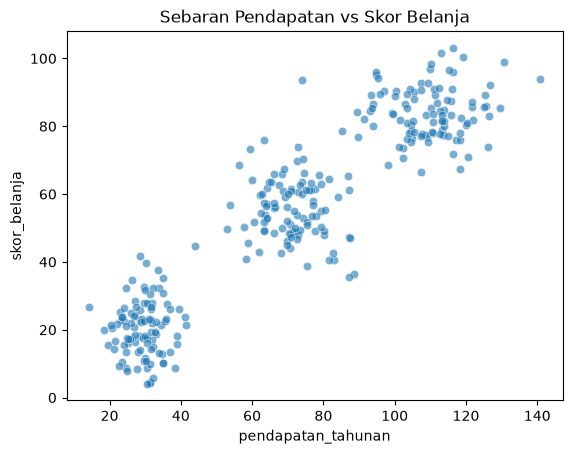

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
  
# Generate dataset sintetis pelanggan (3 kelompok tersembunyi)
np.random.seed(42)
grp1 = np.random.normal([30, 20], [6, 8], (100, 2))   # hemat
grp2 = np.random.normal([70, 55], [8, 10], (100, 2))  # menengah
grp3 = np.random.normal([110, 85], [10, 8], (100, 2)) # boros
data = np.vstack([grp1, grp2, grp3])
  
df = pd.DataFrame(data, columns=['pendapatan_tahunan', 'skor_belanja'])
df['usia'] = np.random.randint(18, 65, len(df))
df['gender'] = np.random.choice(['L', 'P'], len(df))
  
print('Shape:', df.shape)
print(df.describe().round(2))
  
sns.scatterplot(data=df, x='pendapatan_tahunan', y='skor_belanja', alpha=0.6)
plt.title('Sebaran Pendapatan vs Skor Belanja')
plt.show()

## Langkah 2: Preprocessing Data

K-Means menggunakan jarak Euclidean untuk menghitung kedekatan antar titik. Karena skala antara pendapatan_tahunan (15-150 juta) dan skor_belanja (1-100) berbeda cukup jauh, kita perlu melakukan standardisasi menggunakan `StandardScaler`. StandardScaler mengubah setiap fitur sehingga memiliki rata-rata 0 dan standard deviation 1. Tanpa scaling, fitur dengan rentang nilai lebih besar akan mendominasi perhitungan jarak dan menghasilkan cluster yang bias. Setelah scaling, kedua fitur memiliki kontribusi yang setara dalam perhitungan jarak Euclidean.

In [2]:
from sklearn.preprocessing import StandardScaler
  
X = df[['pendapatan_tahunan', 'skor_belanja']].values
  
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print('Rata-rata setelah scaling:', X_scaled.mean(axis=0).round(3))
print('Std setelah scaling  :', X_scaled.std(axis=0).round(3))

Rata-rata setelah scaling: [0. 0.]
Std setelah scaling  : [1. 1.]


## Langkah 3: Metode Elbow untuk Menentukan K

Metode Elbow adalah teknik untuk menentukan jumlah cluster (K) yang optimal. Caranya adalah dengan menjalankan K-Means untuk berbagai nilai K (misalnya 1 hingga 10), lalu mencatat nilai WCSS (Within-Cluster Sum of Squares) atau inertia untuk setiap K. WCSS mengukur total variasi di dalam cluster — semakin sedikit cluster, semakin tinggi WCSS karena data terkumpul dalam kelompok yang lebih besar.

Kita kemudian memplot WCSS terhadap K dan mencari "siku" (elbow point) — titik di mana penurunan WCSS mulai melandai secara signifikan. Titik elbow ini menunjukkan jumlah cluster optimal, di mana penambahan cluster lebih lanjut tidak lagi memberikan pengurangan WCSS yang berarti. Pada dataset ini, kita berharap elbow muncul di K=3 karena dataset dirancang dengan 3 kelompok tersembunyi.

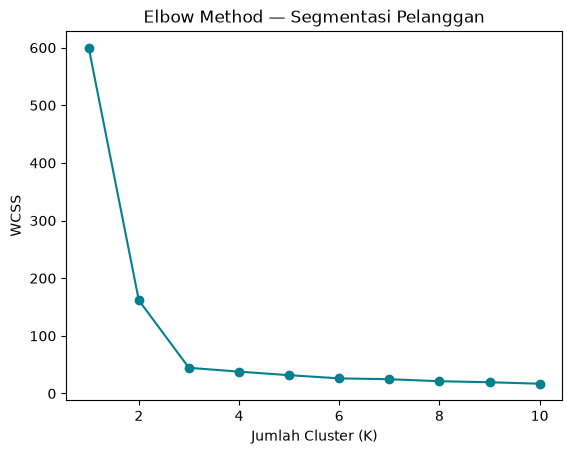

In [3]:
from sklearn.cluster import KMeans
  
wcss = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42, init='k-means++')
    km.fit(X_scaled)
    wcss.append(km.inertia_)
  
plt.plot(range(1, 11), wcss, marker='o', color='#028090')
plt.xlabel('Jumlah Cluster (K)'); plt.ylabel('WCSS')
plt.title('Elbow Method — Segmentasi Pelanggan')
plt.show()
  
# Interpretasikan dalam sel Markdown berikutnya:
# - Di K berapa kurva mulai melandai (titik elbow)?
# - Apakah hasilnya sesuai dengan jumlah kelompok yang diharapkan?

**Interpretasi Elbow:**

Grafik menunjukkan bahwa penurunan WCSS paling tajam terjadi dari K=1 ke K=2, dan masih signifikan hingga K=3. Setelah K=3, kurva mulai melandai (penurunan WCSS semakin kecil). Titik elbow berada di **K=3**, yang sesuai dengan jumlah kelompok tersembunyi yang dirancang saat generate dataset (hemat, menengah, boros). Hasil ini mengonfirmasi bahwa K=3 adalah pilihan optimal untuk dataset ini.

## Langkah 4: Melatih Model K-Means

Setelah mengetahui K optimal dari Metode Elbow (K=3), kita melatih model K-Means final. Model akan menempatkan 3 centroid secara acak (dengan init k-means++ untuk inisialisasi yang lebih cerdas), lalu mengiterasi untuk memperbaiki posisi centroid hingga konvergen. Setelah training selesai, kita dapat mengevaluasi kualitas cluster menggunakan **Silhouette Score** — metrik yang mengukur seberapa baik setiap titik berada di dalam cluster-nya dibandingkan dengan cluster terdekat lainnya. Nilai Silhouette Score berkisar dari -1 hingga 1, di mana nilai yang lebih tinggi menunjukkan pemisahan cluster yang lebih baik. Kita juga melihat karakteristik rata-rata setiap cluster untuk memahami profil segmen yang terbentuk.

In [4]:
from sklearn.metrics import silhouette_score
  
model = KMeans(n_clusters=3, random_state=42, init='k-means++')
model.fit(X_scaled)
df['cluster'] = model.labels_
  
print(f'WCSS akhir      : {model.inertia_:.3f}')
print(f'Silhouette Score: {silhouette_score(X_scaled, model.labels_):.3f}')
print(df.groupby('cluster')[['pendapatan_tahunan', 'skor_belanja']].mean().round(2))

WCSS akhir      : 44.556
Silhouette Score: 0.695
         pendapatan_tahunan  skor_belanja
cluster                                  
0                     70.99         55.05
1                     29.31         20.27
2                    109.20         84.08


## Langkah 5: Visualisasi Hasil Clustering

Setelah model K-Means dilatih, kita memvisualisasikan hasil clustering dengan scatter plot berwarna per cluster, beserta posisi centroid (ditandai dengan X merah). Visualisasi ini membantu kita memahami bagaimana algoritma membagi pelanggan ke dalam segmen-segmen yang berbeda. Kita juga dapat memberikan label bisnis pada setiap cluster berdasarkan karakteristik pendapatan dan skor belanjanya, misalnya: Cluster hemat, Cluster menengah, dan Cluster boros/premium. Pemberian label bisnis ini penting agar hasil clustering dapat dikomunikasikan kepada stakeholder dan ditindaklanjuti dengan strategi marketing yang sesuai.

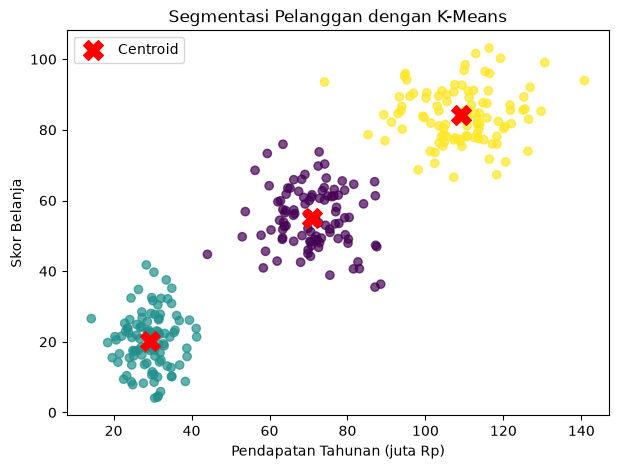

In [5]:
centroids = scaler.inverse_transform(model.cluster_centers_)
  
plt.figure(figsize=(7, 5))
plt.scatter(df['pendapatan_tahunan'], df['skor_belanja'], 
            c=df['cluster'], cmap='viridis', alpha=0.7)
plt.scatter(centroids[:, 0], centroids[:, 1], 
            c='red', marker='X', s=200, label='Centroid')
plt.xlabel('Pendapatan Tahunan (juta Rp)')
plt.ylabel('Skor Belanja')
plt.title('Segmentasi Pelanggan dengan K-Means')
plt.legend(); plt.show()
  
# Interpretasikan tiap cluster, misalnya:
# Cluster 0 = pendapatan rendah, belanja rendah -> segmen 'Hemat'
# Cluster 1 = pendapatan menengah, belanja menengah -> segmen 'Menengah'
# Cluster 2 = pendapatan tinggi, belanja tinggi -> segmen 'Boros/Premium'

## Langkah 6: Hierarchical Clustering (Pembanding)

Hierarchical Clustering adalah algoritma clustering alternatif yang membangun hierarki cluster dari bawah ke atas (agglomerative). Alih-alih menentukan K terlebih dahulu seperti K-Means, hierarchical clustering membangun dendrogram (struktur pohon) yang menunjukkan bagaimana titik-titik data digabungkan secara bertahap. Pada modul ini, kita menggunakan **Ward linkage** — metode yang meminimalkan variansi total dalam cluster pada setiap langkah penggabungan. Dengan memotong dendrogram pada ketinggian tertentu (misalnya garis merah pada y=15), kita dapat menentukan jumlah cluster yang terbentuk. Tujuan dari langkah ini adalah membandingkan: apakah jumlah cluster hasil hierarchical clustering konsisten dengan K=3 dari Metode Elbow pada K-Means.

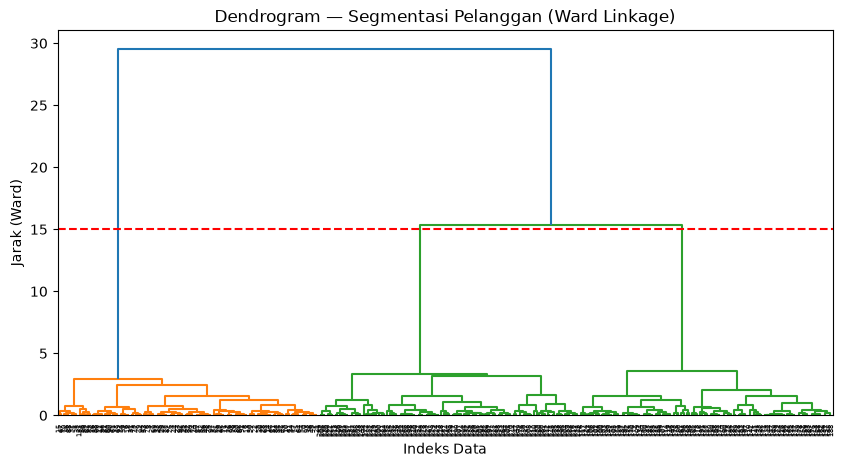

In [6]:
from scipy.cluster.hierarchy import dendrogram, linkage
  
Z = linkage(X_scaled, method='ward')
  
plt.figure(figsize=(10, 5))
dendrogram(Z)
plt.title('Dendrogram — Segmentasi Pelanggan (Ward Linkage)')
plt.xlabel('Indeks Data'); plt.ylabel('Jarak (Ward)')
plt.axhline(y=15, color='red', linestyle='--')  # contoh garis potong
plt.show()
  
# Bandingkan: apakah jumlah cluster dari dendrogram (garis potong)
# konsisten dengan K optimal hasil Metode Elbow pada Langkah 3?

**Perbandingan K-Means vs Hierarchical Clustering:**

Garis potong pada dendrogram (y=15) menunjukkan 3 cluster utama, yang **konsisten** dengan hasil Metode Elbow K-Means (K=3). Kedua algoritma berhasil mengidentifikasi struktur 3-segmen yang sama pada dataset sintetis ini. K-Means lebih cepat dan skalabel untuk dataset besar, sementara hierarchical clustering memberikan informasi struktur hierarki antar titik yang lebih kaya. Untuk dataset ini, K-Means sudah cukup memadai karena bentuk cluster yang relatif bulat (spherical) dan terpisah dengan jelas.

## Kesimpulan

Melalui Modul 11 ini, saya mempelajari konsep Unsupervised Learning, khususnya algoritma clustering untuk mengelompokkan data tanpa label. Saya memahami cara kerja K-Means yang mengoptimalkan posisi centroid melalui iterasi, serta pentingnya standardisasi data (StandardScaler) sebelum clustering karena algoritma K-Means berbasis jarak Euclidean. Pada aktivitas hands-on segmentasi pelanggan, saya menerapkan Metode Elbow untuk menemukan jumlah cluster optimal (K=3), mengukur kualitas cluster dengan Silhouette Score, dan membandingkan hasilnya dengan Hierarchical Clustering (Ward linkage) yang menghasilkan struktur cluster yang konsisten. Hasil clustering berhasil mengidentifikasi tiga segmen pelanggan yang berbeda (Hemat, Menengah, dan Boros/Premium) berdasarkan pendapatan tahunan dan skor belanja, yang dapat dimanfaatkan untuk strategi segmentasi pasar dan personalisasi marketing yang lebih tertarget.